In [107]:
%load_ext autoreload
%autoreload 2
import numpy as np
from pathlib import Path
import tifffile
import mbo_utilities as mbo
import fastplotlib as fpl
import lbm_suite2p_python as lsp
import suite2p

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
corr = r"/home/flynn/lbm_data/corrected"
files = mbo.get_files(corr, 'bin', 5)
ops_files = mbo.get_files(corr, 'ops.npy', 5)

len(files)

1

In [109]:
ops = lsp.load_ops(ops_files[0])

In [110]:
bin_data = np.memmap(files[0], shape=(ops["nframes"], ops["Lx"], ops["Ly"]), dtype=np.int16)
bin_data.shape

(1437, 448, 448)

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
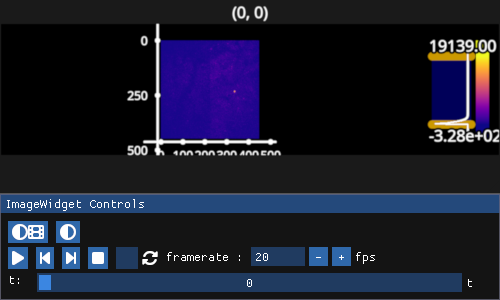

In [111]:
iw = fpl.ImageWidget(data=bin_data)
iw.show()

In [37]:
data_list = [tifffile.memmap(file) for file in tiffs]
name_list = [Path(x).parent.name for x in tiffs]
name_list

['false', '500', 'true', '50']

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
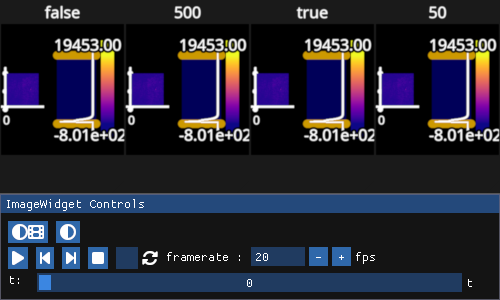

In [38]:
iw = fpl.ImageWidget(data=data_list, names=name_list, figure_shape=(1, 4))
iw.show()

In [28]:
iw.close()

In [9]:
zplane = "plane1"
num = int(Path(zplane).stem.removeprefix("plane"))

1

In [3]:
mbo.save_as(scan, "/home/flynn/lbm_data/bin", overwrite=True, target_chunk_mb=500, fix_phase=True, ext='bin', planes=[7])

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/2 [00:00<?, ?it/s]

Time elapsed: 0 minutes 4 seconds.


In [4]:
mbo.save_as(scan, "/home/flynn/lbm_data/bin", overwrite=True, target_chunk_mb=500, fix_phase=True, ext='tif', planes=[7])

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/2 [00:00<?, ?it/s]

Time elapsed: 0 minutes 3 seconds.


In [5]:
tiff_file = mbo.get_files("/home/flynn/lbm_data/bin", 'tif', 3)
tiff_file

['/home/flynn/lbm_data/bin/plane_08.tif']

In [6]:
def _write_raw_binary(tiff_path, out_path):
    data = tifffile.memmap(tiff_path)
    out_path = Path(out_path).with_suffix(".bin")

    if data.ndim != 3:
        raise ValueError("Must be assembled, 3D (T, Y, X)")

    nframes, x, y = data.shape
    bf = BinaryFile(Ly=y, Lx=x, filename=str(Path(out_path)), n_frames=nframes, dtype=np.int16)

    bf[:] = data
    bf.close()

In [47]:
_write_raw_binary("/home/flynn/lbm_data/bin/plane_08.tif", "/home/flynn/lbm_data/bin/test.bin")

In [7]:
file1 = "/home/flynn/lbm_data/bin/test.bin"
file2 = "/home/flynn/lbm_data/bin/plane7/data_raw.bin"

In [8]:

n_frames, Ly, Lx = ops["nframes"], ops["Ly"], ops["Lx"]
reg_file = file1

NameError: name 'ops' is not defined

In [54]:
reg_file = ops["reg_file"]
with suite2p.io.BinaryFile(Ly=Ly, Lx=Lx, filename=file1, n_frames=n_frames) as f_reg:
    # ops = suite2p.pipeline(f_reg, None, None, None, True, ops, stat=None)
    mov1 = f_reg
    
with suite2p.io.BinaryFile(Ly=Ly, Lx=Lx, filename=file2, n_frames=n_frames) as f_reg:
    # ops = suite2p.pipeline(f_reg, None, None, None, True, ops, stat=None)
    mov2 = f_reg

In [57]:
np.dtype(mov1), np.dtype(mov2)

(dtype('int16'), dtype('int16'))

In [58]:
fpl.ImageWidget(data=[mov1, mov2]).show()

TypeError: If passing a list to `data` all elements must be an array-like type representing an n-dimensional image. You have passed the following types:
[<class 'suite2p.io.binary.BinaryFile'>, <class 'suite2p.io.binary.BinaryFile'>]

In [7]:
input_path = "/home/flynn/lbm_data/bin"
binfiles = mbo.get_files(input_path, 'bin', 3)
binfiles

['/home/flynn/lbm_data/bin/plane7/data_raw.bin']

In [6]:
data = np.memmap(binfiles[0])
data.dtype

dtype('uint8')

## Need to test
- keep_reg = True/False
- keep_raw = True/False

In [9]:
ops = lsp.run_plane(binfiles[0], keep_reg=True)

Saving to None...
Applying user ops: {}
NOTE: not registered / registration forced with ops['do_registration']>1
      (no previous offsets to delete)
NOTE: applying default /home/flynn/.suite2p/classifiers/classifier_user.npy
----------- REGISTRATION
Reference frame, 6.99 sec.
Registered 500/1437 in 7.91s
Registered 1000/1437 in 15.39s
Registered 1437/1437 in 21.51s
----------- Total 29.10 sec
----------- ROI DETECTION
Binning movie in chunks of length 17


ValueError: Maximum allowed size exceeded

In [8]:
test = r"/home/flynn/lbm_data/tiff/plane7/ops.npy"
ops = lsp.load_ops(test)

In [12]:
ops["Lx"], ops["Ly"], ops["nframes"]

KeyError: 'dtype'

In [31]:
from pathlib import Path
import tifffile
try:
    from suite2p.io.binary import BinaryFile
except ImportError:
    BinaryFile = None

def write_ops(metadata: dict, base_path: str | Path, planes):
    base_path = Path(base_path).expanduser().resolve()
    del metadata["si"]

    if isinstance(planes, int):
        planes=[planes]
    for plane_idx in planes:
        plane_dir = Path(base_path) / f"plane{plane_idx}"
        
        raw_bin = plane_dir.parent.joinpath("data_raw.bin")
        ops_path = plane_dir.parent.parent.joinpath("ops.npy")
        
        # TODO: This is not an accurate way to get a metadata value that should not have 
        #        to be calculated. We use shape to account for the trimmed pixels
        shape = metadata["shape"]
        nt = shape[0]
        Ly = shape[-2]
        Lx = shape[-1]
        dx, dy = metadata.get("pixel_resolution", [2, 2])
        ops = {
            "Ly": Ly,
            "Lx": Lx,
            "fs": np.round(metadata.get("frame_rate"), 2),
            "nframes": nt,
            "raw_file": str(raw_bin.resolve()),
            "reg_file": str(raw_bin.resolve()),
            "dx": dx,
            "dy": dy,
            "metadata": metadata,
        }
        np.save(ops_path, ops)

def tiff_to_suite2p_binary(tiff_path, out_bin, dtype="int16"):
    """
    Convert a 3D ScanImage TIFF (T, Y, X) to a Suite2p raw binary
    that can be picked up by `suite2p.run_plane(..., input_format='binary')`.
    """
    data = tifffile.memmap(str(tiff_path))
    metadata = mbo.get_metadata(tiff_path)
    
    ops_out = Path(out_bin).parent.joinpath("ops.npy")
    print(ops_out)
    
    if data.ndim != 3:
        raise ValueError("TIFF must be 3D (T, Y, X)")

    T, Y, X = data.shape
    out_bin = Path(out_bin).with_suffix(".bin")
    out_bin.parent.mkdir(exist_ok=True)

    bf = BinaryFile(Ly=Y, Lx=X, filename=str(out_bin), n_frames=T, dtype=dtype)
    bf[:] = data.astype(dtype)  
    bf.close()
    write_ops(metadata, ops_out, 7)

    print(f"Wrote Suite2p binary '{out_bin}' – {T} × ({Y},{X}) @ {dtype}")

tiff = "/home/flynn/lbm_data/demo/assembled/plane_08.tif"
bin_out = "/home/flynn/lbm_data/plane7/data_raw.bin"
ops_out = "/home/flynn/lbm_data/plane7/ops.npy"

tiff_to_suite2p_binary(tiff, bin_out)

/home/flynn/lbm_data/plane7/ops.npy
Wrote Suite2p binary '/home/flynn/lbm_data/plane7/data_raw.bin' – 1437 × (448,448) @ int16


In [22]:
ops_out = "/home/flynn/lbm_data/plane7/ops.npy"
ops = lsp.load_ops(ops_out)

In [34]:
lsp.run_plane()

ValueError: Input path must be a file, not a directory: /home/flynn/lbm_data/plane7